# Exploratory Data Analysis for "Predicting Irrigation Need" !

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

In [3]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [5]:
train.columns

Index(['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

In [6]:
target = 'Irrigation_Need'
id_col = 'id'

In [7]:
df_eda = train.drop(columns=[id_col], errors='ignore')



Feature Summary:
                    feature    dtype  unique_values  missing_values  \
0                 Soil_Type   object              4               0   
1                   Soil_pH  float64            341               0   
2             Soil_Moisture  float64           5223               0   
3            Organic_Carbon  float64            131               0   
4   Electrical_Conductivity  float64            341               0   
5             Temperature_C  float64           2934               0   
6                  Humidity  float64           6475               0   
7               Rainfall_mm  float64          19308               0   
8            Sunlight_Hours  float64            701               0   
9            Wind_Speed_kmh  float64           1935               0   
10                Crop_Type   object              6               0   
11        Crop_Growth_Stage   object              4               0   
12                   Season   object              3        

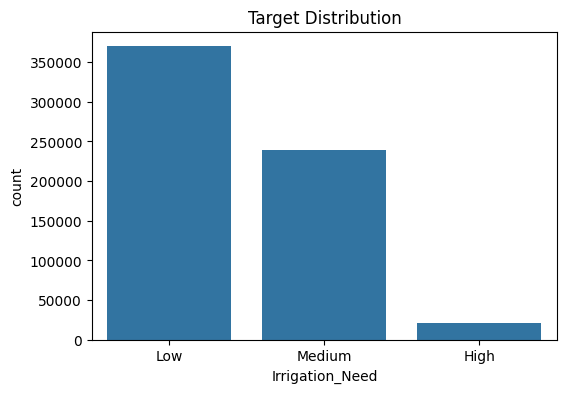

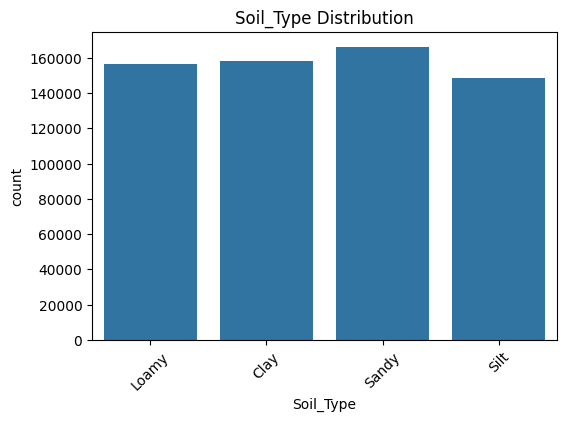

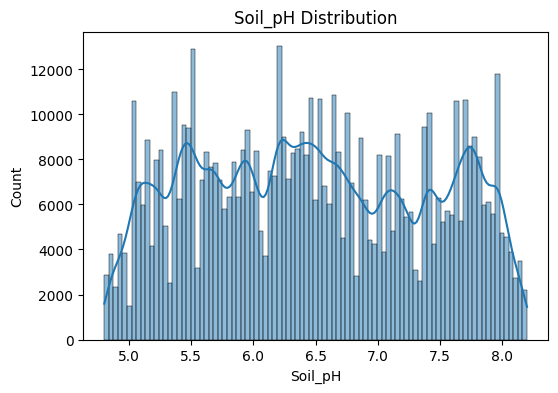

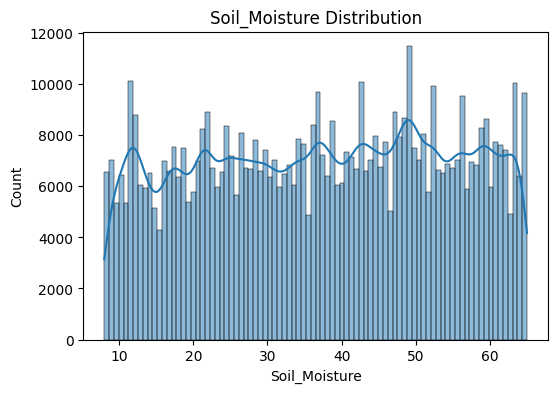

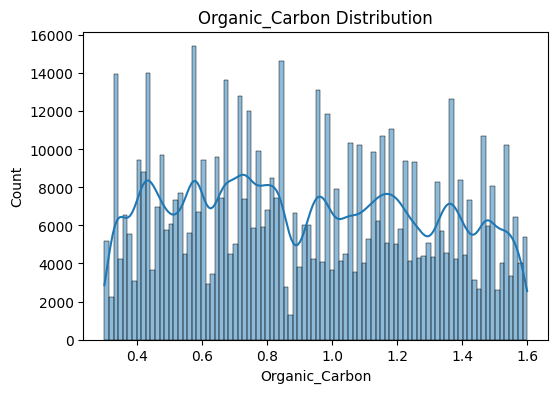

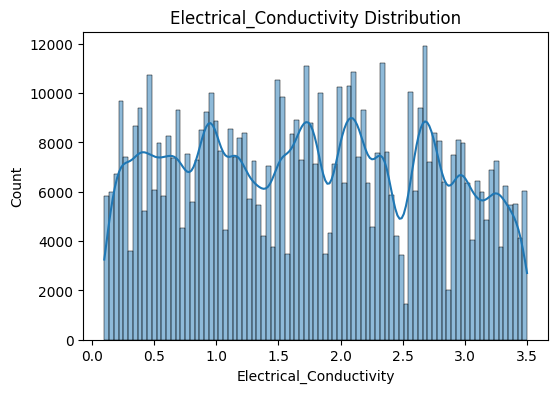

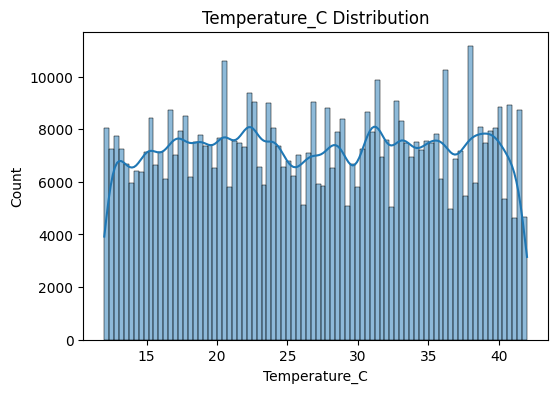

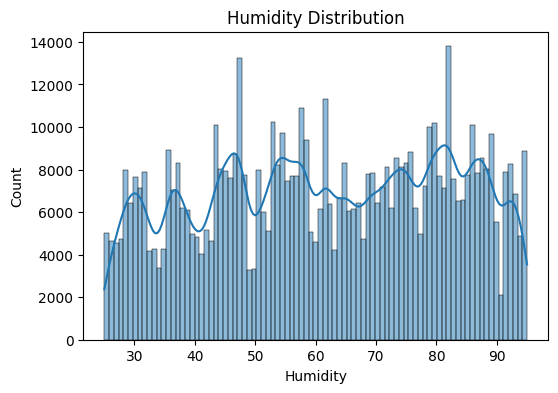

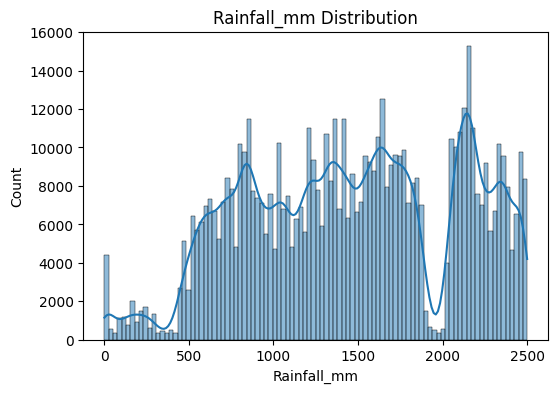

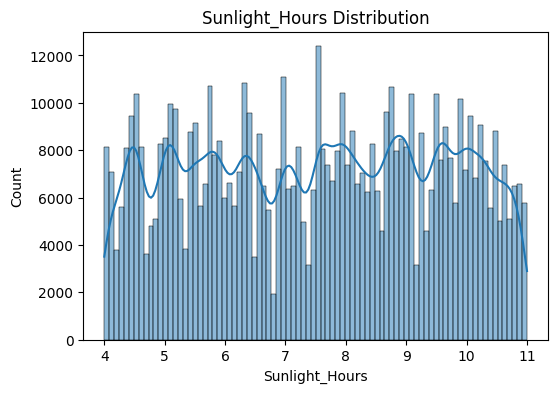

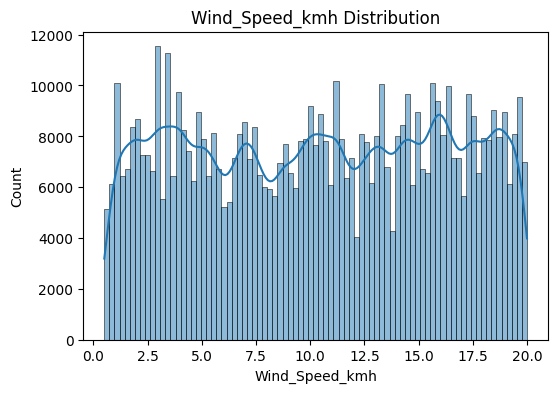

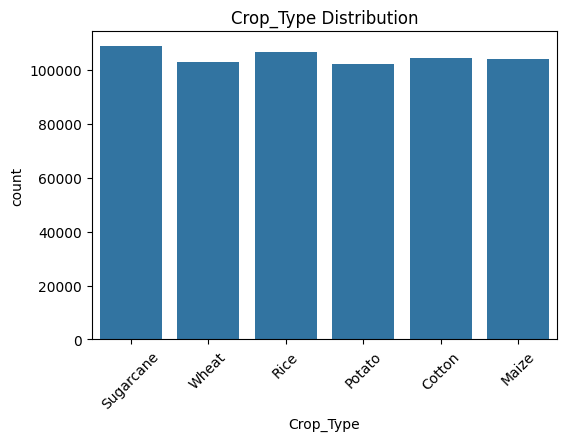

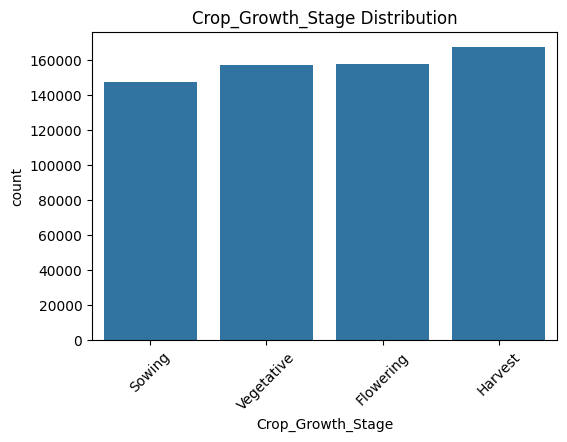

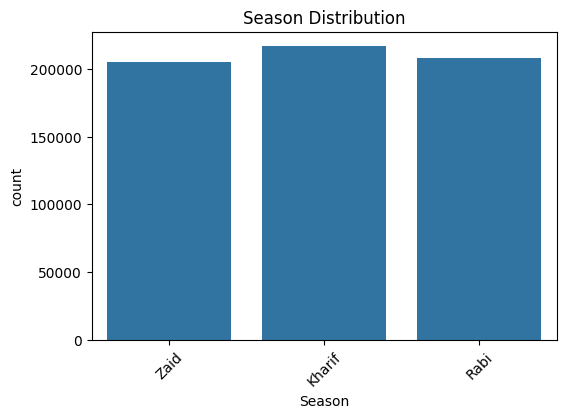

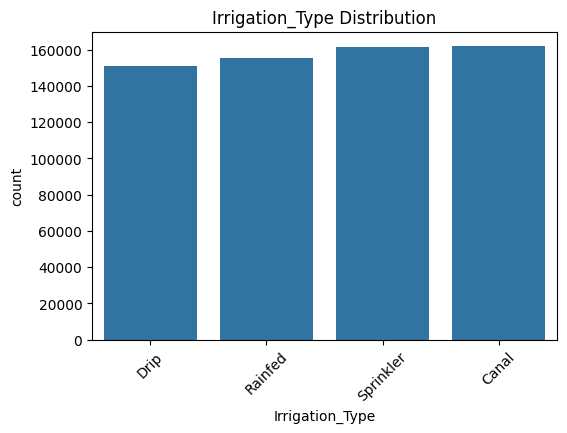

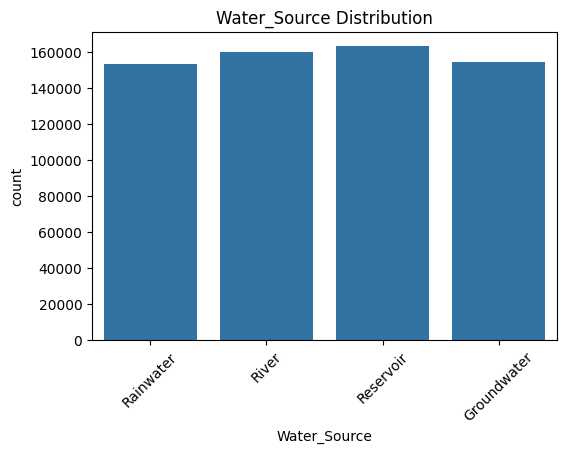

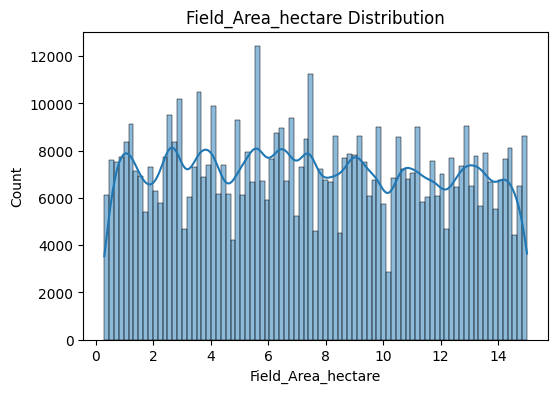

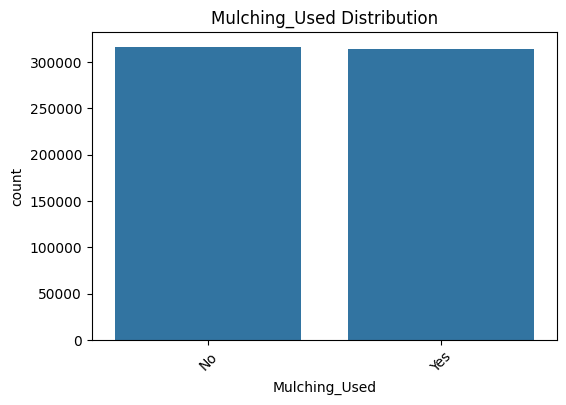

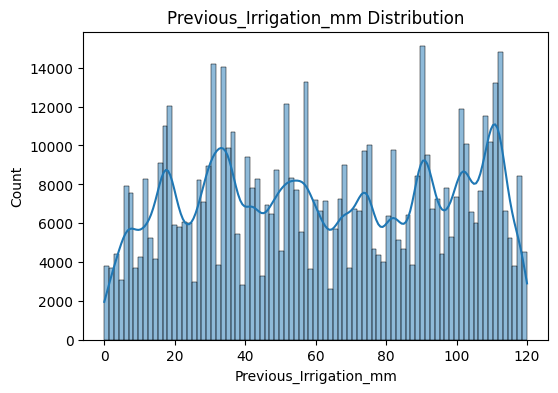

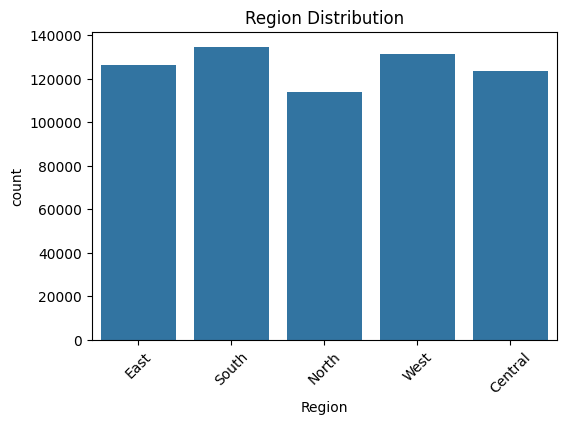

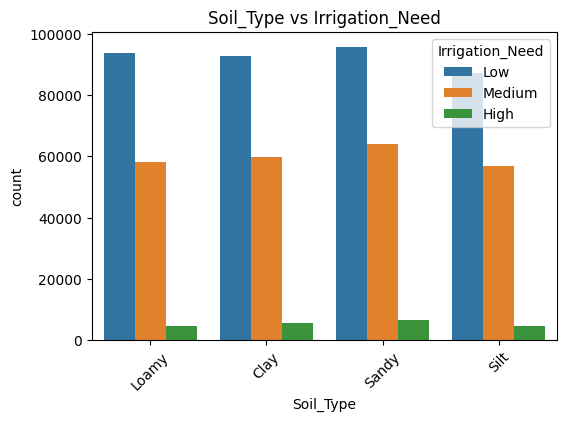

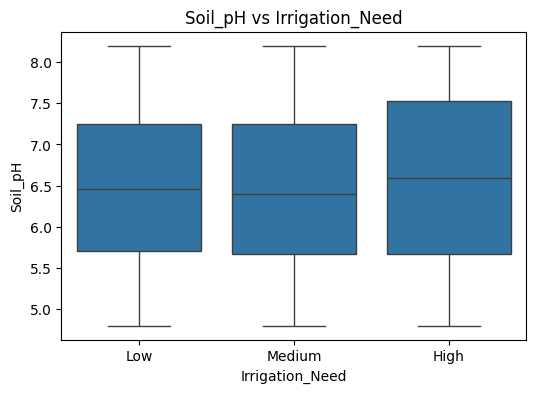

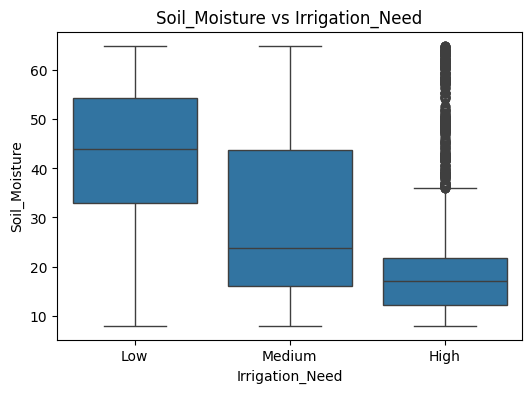

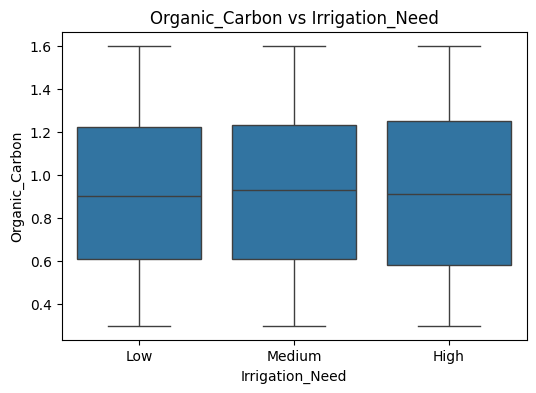

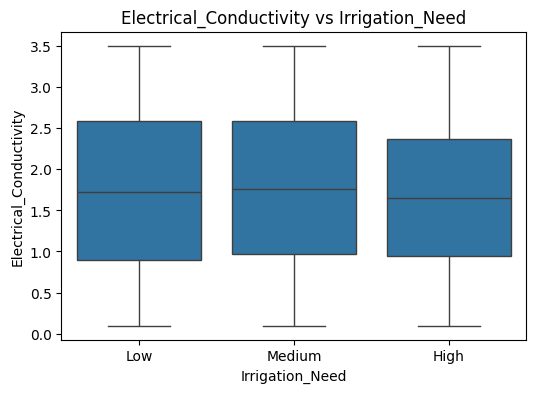

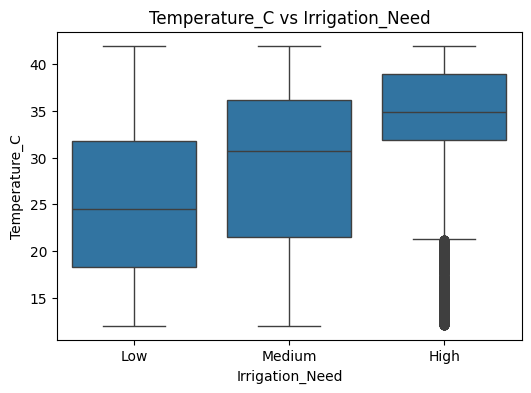

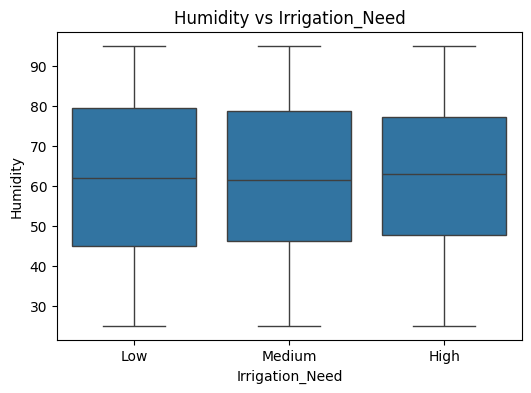

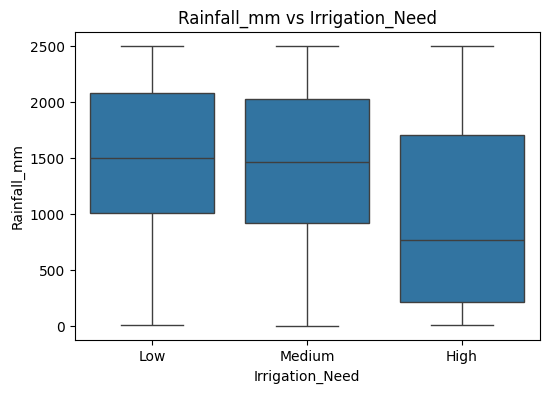

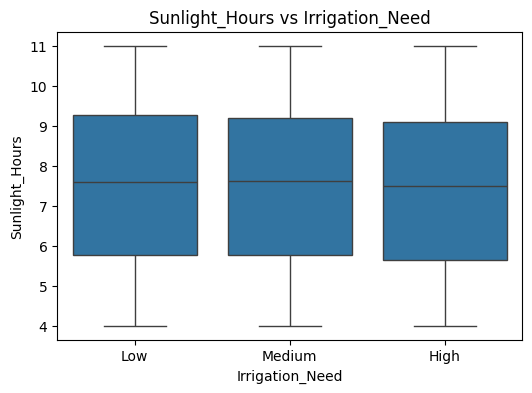

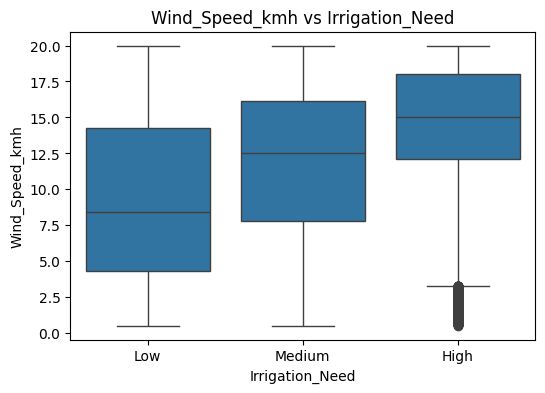

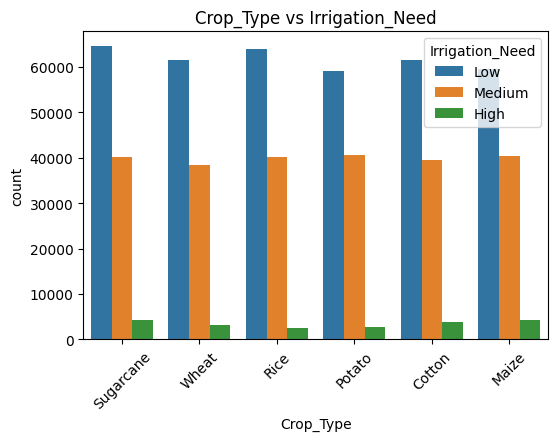

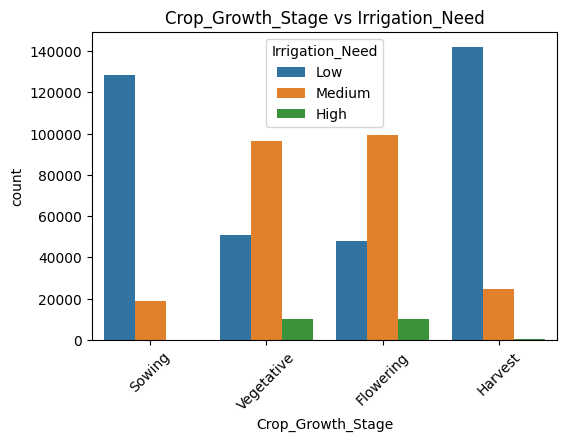

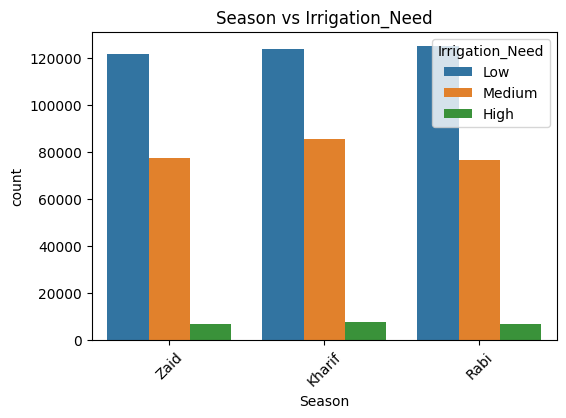

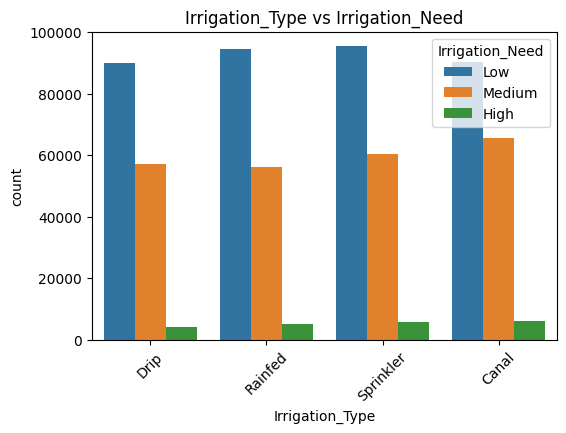

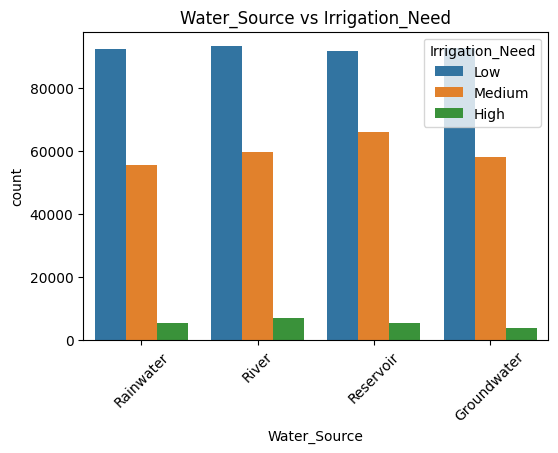

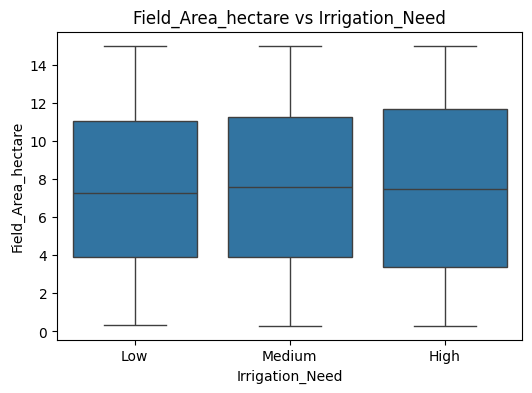

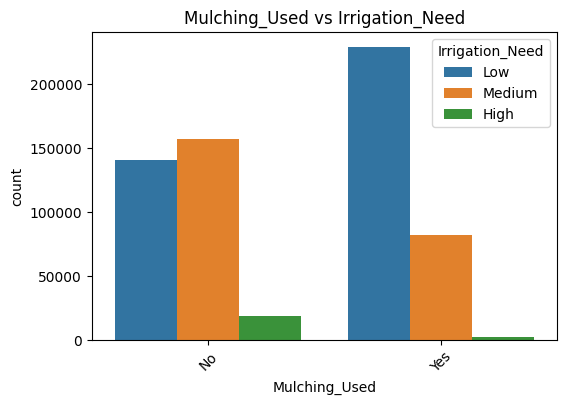

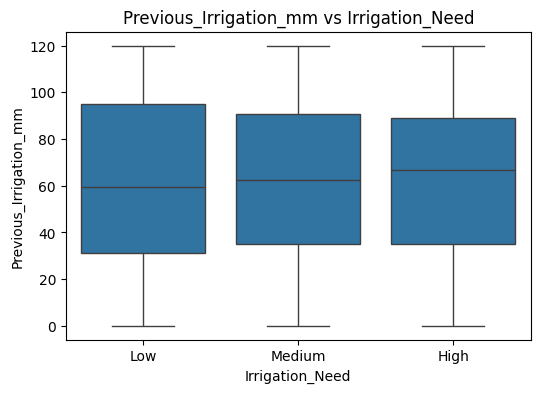

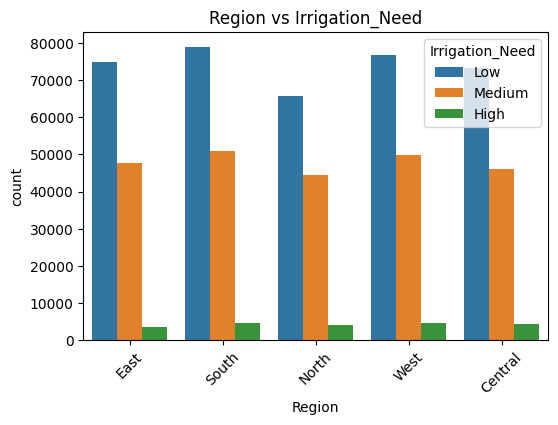

In [8]:
def get_feature_type(series):
    if series.dtype == 'object':
        return 'categorical'
    elif series.nunique() < 15:
        return 'categorical'
    else:
        return 'numerical'

feature_info = []

for col in df_eda.columns:
    info = {
        'feature': col,
        'dtype': df_eda[col].dtype,
        'unique_values': df_eda[col].nunique(),
        'missing_values': df_eda[col].isnull().sum(),
        'feature_type': get_feature_type(df_eda[col])
    }
    feature_info.append(info)

feature_summary = pd.DataFrame(feature_info)
print("\nFeature Summary:")
print(feature_summary)

plt.figure(figsize=(6,4))

if get_feature_type(df_eda[target]) == 'categorical':
    sns.countplot(x=df_eda[target])
else:
    sns.histplot(df_eda[target], kde=True)

plt.title("Target Distribution")
plt.show()


for col in df_eda.columns:
    if col == target:
        continue

    plt.figure(figsize=(6,4))

    if get_feature_type(df_eda[col]) == 'categorical':
        sns.countplot(x=df_eda[col])
        plt.xticks(rotation=45)
    else:
        sns.histplot(df_eda[col], kde=True)

    plt.title(f"{col} Distribution")
    plt.show()

for col in df_eda.columns:
    if col == target:
        continue

    plt.figure(figsize=(6,4))

    if get_feature_type(df_eda[col]) == 'categorical':
        sns.countplot(x=col, hue=target, data=df_eda)
        plt.xticks(rotation=45)
    else:
        if get_feature_type(df_eda[target]) == 'categorical':
            sns.boxplot(x=target, y=col, data=df_eda)
        else:
            sns.scatterplot(x=df_eda[col], y=df_eda[target])

    plt.title(f"{col} vs {target}")
    plt.show()

### 